import numpy for numerical.
pandas for data handling
matplotlib for graph and visualization.
import other ml tools from sklearn.

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

Loads the dataset of linkked to perform Gaussain Naive Bayes

In [48]:
df = pd.read_csv("linkedin.csv", encoding='latin1', low_memory=False)
df.head()

,Unnamed: 0,ageEstimate,companyFollowerCount,companyHasLogo,companyName,companyStaffCount,companyUrl,companyUrn,connectionsCount,country,...,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40
0,0,41,198859.0,5a92c12e-0a20-482b-95ec-e705a6294730-2.png,Commonwealth Bank,32905,http://www.commbank.com.au/,urn:li:company:2848,500,au,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,41,198859.0,5a92c12e-0a20-482b-95ec-e705a6294730-2.png,Commonwealth Bank,32905,http://www.commbank.com.au/,urn:li:company:2848,500,au,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,41,10047.0,b1c3fd9a-8f21-48f8-8321-d773b1ff3cb7-2.png,CommSec,619,http://www.commsec.com.au,urn:li:company:2851,500,au,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,41,198859.0,5a92c12e-0a20-482b-95ec-e705a6294730-2.png,Commonwealth Bank,32905,http://www.commbank.com.au/,urn:li:company:2848,500,au,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,30,300723.0,0f982557-a907-409e-af20-1feb0e0813cd-2.png,PayPal,22522,http://www.paypal.com,urn:li:company:1482,500,au,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df.columns

Index(['Unnamed: 0', 'ageEstimate', 'companyFollowerCount', 'companyHasLogo',
       'companyName', 'companyStaffCount', 'companyUrl', 'companyUrn',
       'connectionsCount', 'country', 'endDate', 'followable',
       'followersCount', 'genderEstimate', 'hasPicture', 'isPremium',
       'mbrLocation', 'mbrLocationCode', 'mbrTitle', 'memberUrn',
       'posLocation', 'posLocationCode', 'posTitle', 'positionId', 'startDate',
       'avgMemberPosDuration', 'avgCompanyPosDuration', 'Unnamed: 27',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35',
       'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39',
       'Unnamed: 40'],
      dtype='object')

 Select only required columns for analysis

In [50]:
df = df[['ageEstimate', 'companyFollowerCount', 'connectionsCount', 'followersCount', 'genderEstimate']]

show the null values sum in dataset

In [51]:
df.isnull().sum()

ageEstimate                0
companyFollowerCount    1466
connectionsCount           0
followersCount             3
genderEstimate          3968
dtype: int64

visualize the missing value in dataset

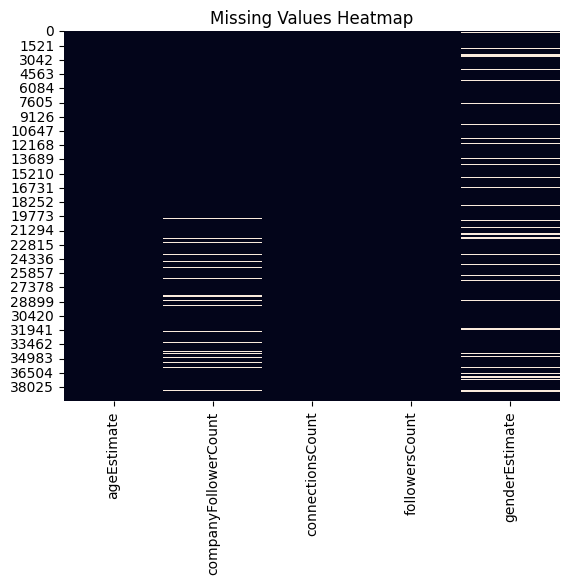

In [52]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

to manage row with missing values (remove those rows). lean the dataset

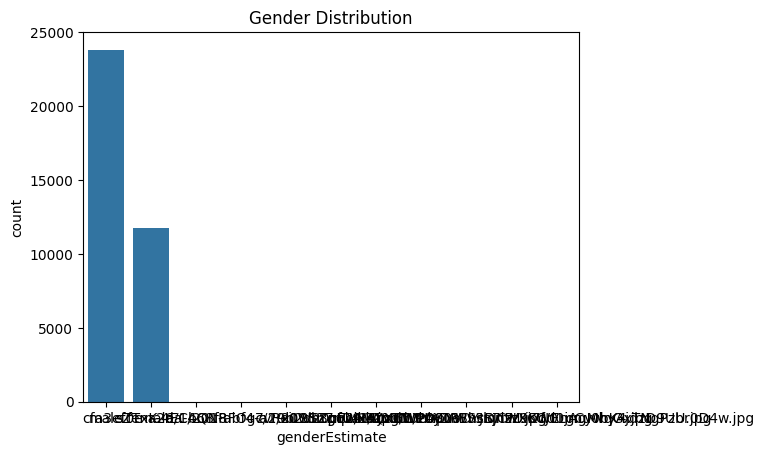

In [53]:
sns.countplot(x='genderEstimate', data=df)
plt.title("Gender Distribution")
plt.show()

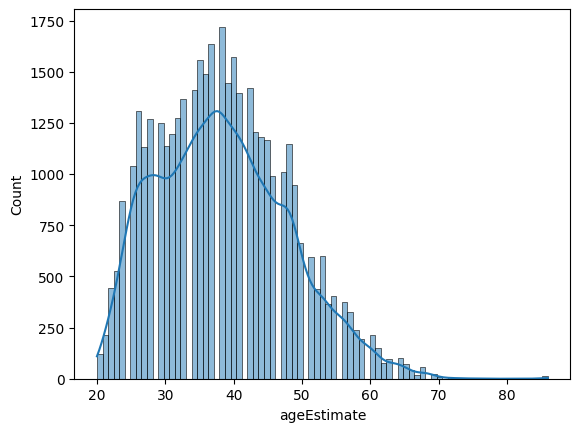

In [54]:
sns.histplot(df['ageEstimate'], kde=True)
plt.show()

In [55]:
# Independent variables (input features)
X = df[['ageEstimate', 'companyFollowerCount']]

# Dependent variable (target)
y = df['genderEstimate']

In [56]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
# Check missing values in full dataset
print(df.isnull().sum())

# Check after splitting
print("X_train NaN:\n", pd.DataFrame(X_train).isnull().sum())
print("y_train NaN:\n", pd.Series(y_train).isnull().sum())

ageEstimate                0
companyFollowerCount    1466
connectionsCount           0
followersCount             3
genderEstimate          3968
dtype: int64
X_train NaN:
 ageEstimate                0
companyFollowerCount    1152
dtype: int64
y_train NaN:
 3142


In [58]:
df = df.fillna(df.mean(numeric_only=True))

In [59]:
# Convert categorical to numeric
df['genderEstimate'] = df['genderEstimate'].astype('category').cat.codes

In [60]:
X = df.drop('genderEstimate', axis=1)
y = df['genderEstimate']

Train-Test Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Train Gaussian Naive Bayes Model

In [71]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [62]:
df.dtypes

ageEstimate               int64
companyFollowerCount    float64
connectionsCount         object
followersCount           object
genderEstimate             int8
dtype: object

In [63]:
df = df.select_dtypes(include=[np.number])

In [64]:
df.columns

Index(['ageEstimate', 'companyFollowerCount', 'genderEstimate'], dtype='object')

In [65]:
df['target'] = (df['companyFollowerCount'] > df['companyFollowerCount'].mean()).astype(int)

In [66]:
X = df[['ageEstimate']]
y = df['target']

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [67]:
from sklearn.linear_model import LinearRegression

X = df[['ageEstimate']]
y = df['companyFollowerCount']

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [69]:
y_pred = model.predict(X_test)

In [70]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# For multiclass, TP/FP/TN/FN is not simple, but accuracy works well
accuracy = accuracy_score(y_test, y_pred)

# Use macro average for multiclass
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Error Rate: {error_rate * 100:.2f}%")
print(f"Precision (Macro): {precision * 100:.2f}%")
print(f"Recall (Macro): {recall * 100:.2f}%")

Confusion Matrix:
 [[6762    0]
 [1144    0]]
Accuracy: 85.53%
Error Rate: 14.47%
Precision (Macro): 42.76%
Recall (Macro): 50.00%


/home/pict/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In this project, I used a LinkedIn dataset and selected relevant features like age, followers, and connections. I cleaned the data by removing missing values and then applied Gaussian Naive Bayes for classification. The model predicts gender based on user features. Finally, I evaluated performance using confusion matrix, accuracy, precision, and recall.